# Configuração 1 — equalizar antes de suavizar

**ruído → equalização → Gaussiano 5×5 → high-boost**

Diferença para a configuração 2: realça o contraste **antes** de remover o ruído.

In [1]:
import sys
sys.path.insert(0, "../src")

from pdi import pipeline
from pdi.gustavo import io_utils
from pdi.gustavo import operacoes_pontuais as op
from pdi.heloisa import ruido, suavizacao
from pdi.joao import agucamento, metricas

IMAGENS = {
    "ISIC_0014049": "../data/originais/ISIC_0014049.jpg",  # baixo contraste
    "ISIC_7236365": "../data/originais/ISIC_7236365.jpg",  # pelos densos
    "ISIC_0021531": "../data/originais/ISIC_0021531.jpg",  # bordas difusas
}

CONFIG = [
    ("degradada",  lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("equalizada", lambda im: op.equalizar_histograma(im)),
    ("suavizada",  lambda im: suavizacao.filtro_gaussiano(im, tamanho=5, sigma=1.0)),
    ("agucada",    lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
]

## Execução nas 3 imagens

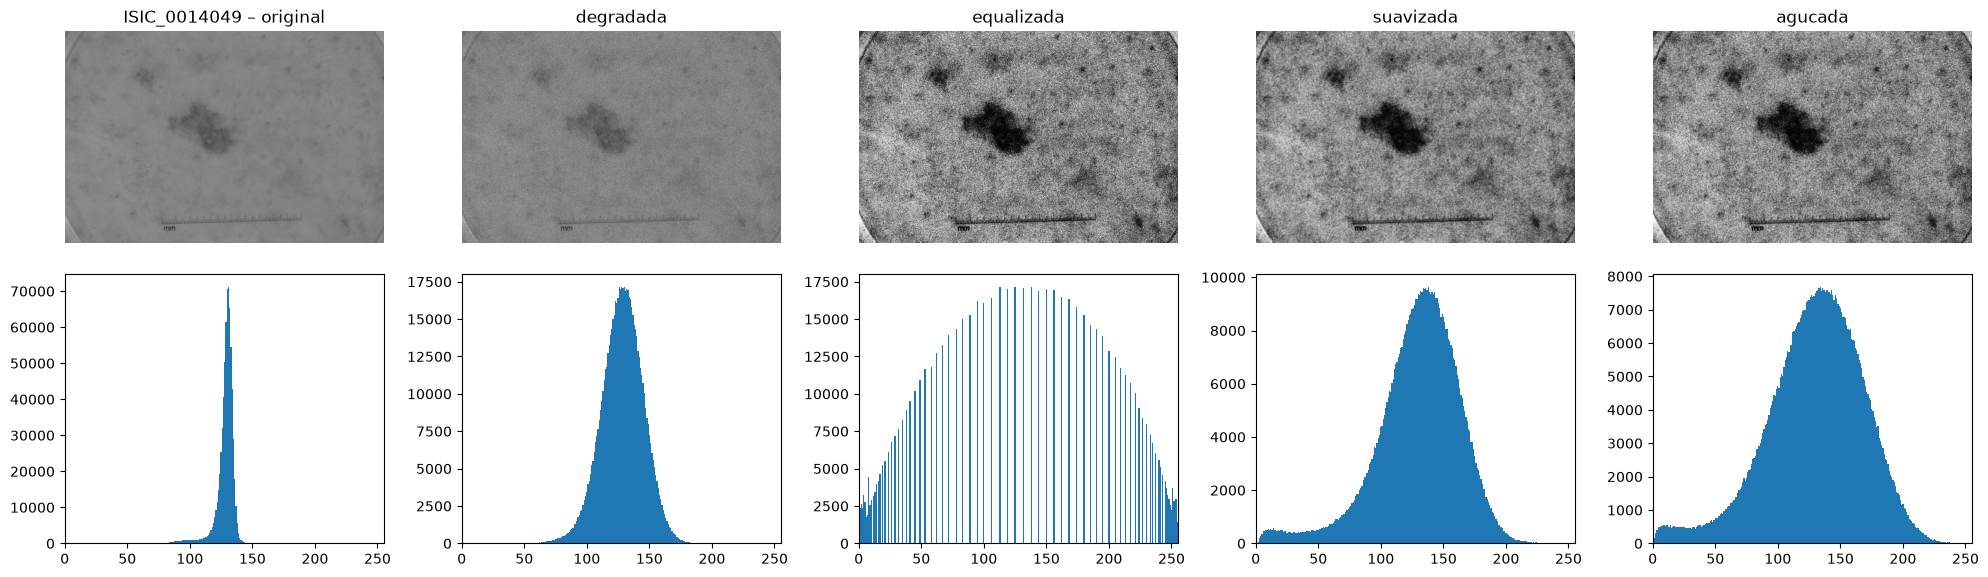

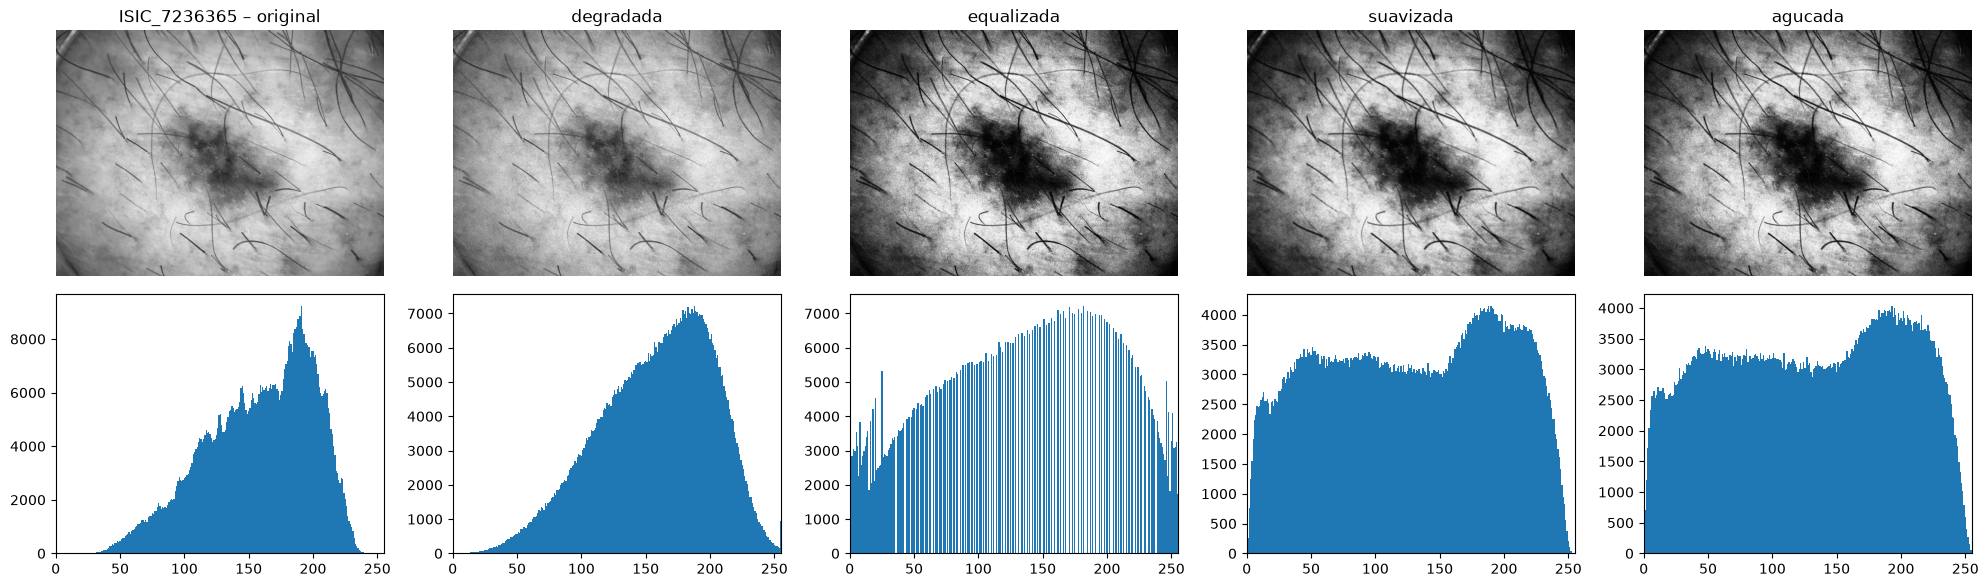

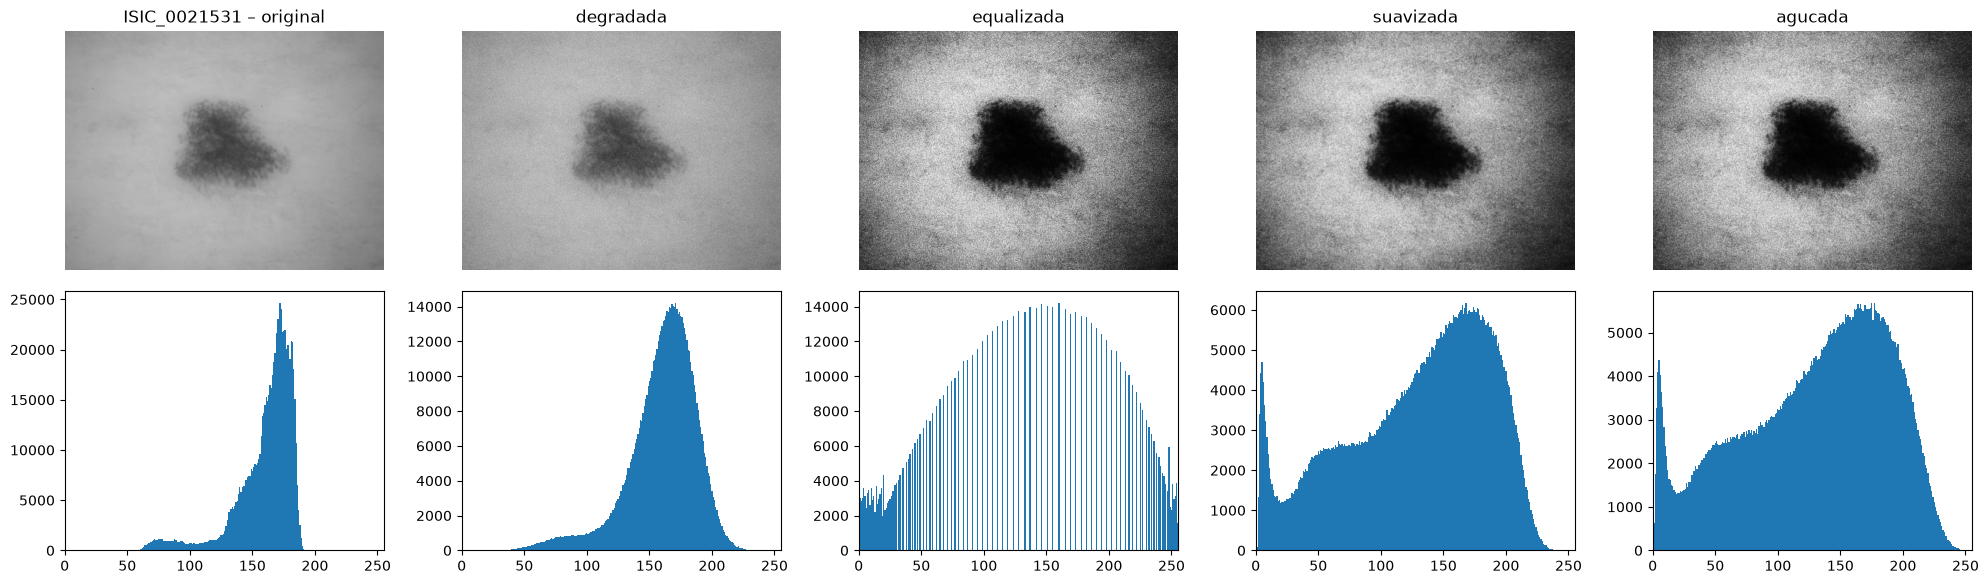

In [2]:
resultados = {}
for nome, caminho in IMAGENS.items():
    img = io_utils.carregar_cinza(caminho, largura_max=1024)
    resultados[nome] = pipeline.executar(img, CONFIG)
    io_utils.mostrar(pipeline.imagens(resultados[nome]), [f"{nome} – {e}" if e == "original" else e
                                                         for e in pipeline.nomes(resultados[nome])])

## Métricas (referência: original sem ruído)

In [3]:
print(f"{'Imagem':<14}{'Estágio':<12}{'PSNR (dB)':>10}{'SSIM':>8}")
for nome, res in resultados.items():
    original = res[0][1]
    for etapa, im in res[1:]:
        print(f"{nome:<14}{etapa:<12}{metricas.psnr(original, im):>10.2f}{metricas.ssim(original, im):>8.3f}")
    print()

Imagem        Estágio      PSNR (dB)    SSIM


ISIC_0014049  degradada        24.60   0.240


ISIC_0014049  equalizada       11.08   0.022


ISIC_0014049  suavizada        19.11   0.205


ISIC_0014049  agucada          17.51   0.119



...

ISIC_7236365  agucada          15.52   0.513



ISIC_0021531  degradada        24.60   0.232


ISIC_0021531  equalizada       11.58   0.035


ISIC_0021531  suavizada        14.41   0.276


ISIC_0021531  agucada          14.10   0.168



## Veredito

| | Config 1 | Config 2 |
|---|---|---|
| Contraste final (desvio, ISIC_0014049) | **≈ 39** | ≈ 13 |
| SSIM final | 0,12 / **0,51** / 0,17 | **0,36** / 0,46 / **0,32** |
| PSNR final (dB) | **17,5** / 15,5 / 14,1 | 16,4 / **17,6** / **17,4** |

*(ordem: ISIC_0014049 / ISIC_7236365 / ISIC_0021531)*

- ✅ **Maior ganho de contraste:** a única que torna a lesão da ISIC_0014049 realmente visível.
- ❌ **A equalização amplifica o ruído:** o SSIM despenca logo após ela (0,02–0,23) e o Gaussiano não recupera.
- ❌ **High-boost realça o ruído que sobrou** e a vinheta do dermatoscópio escurece os cantos (ISIC_0021531).
- **Melhor para:** imagem de contraste muito baixo ou escura (ver teste abaixo). **Pior em fidelidade.**

## Teste com imagem nova
Na imagem escura, a equalização revela a lesão (compare com a configuração 2).

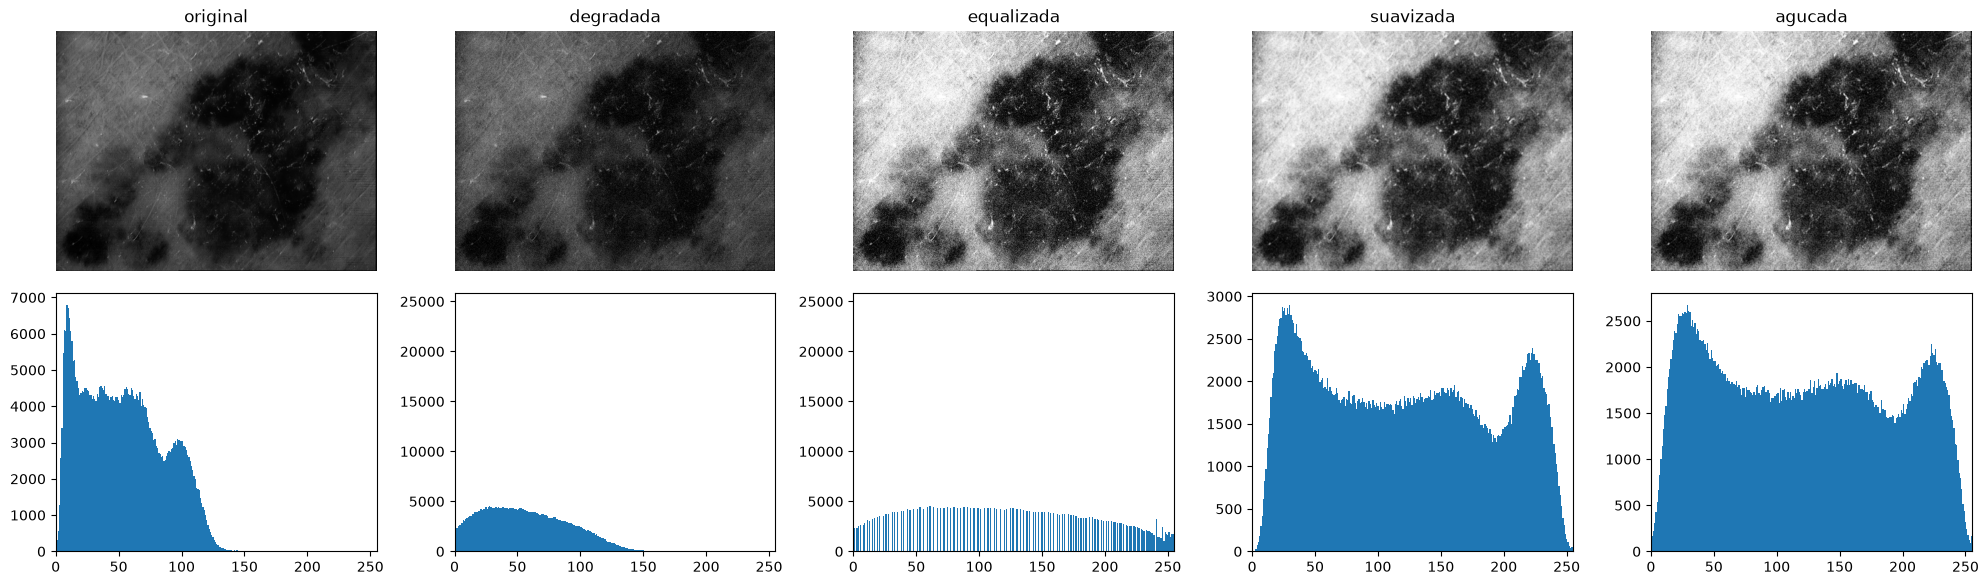

degradada    PSNR  24.94 dB   SSIM 0.397
equalizada   PSNR   9.61 dB   SSIM 0.143


suavizada    PSNR  10.25 dB   SSIM 0.456


agucada      PSNR  10.18 dB   SSIM 0.375


In [4]:
IMAGEM_TESTE = "../data/originais/ISIC_0112420.jpg"  # troque por qualquer imagem

img = io_utils.carregar_cinza(IMAGEM_TESTE, largura_max=1024)
res = pipeline.executar(img, CONFIG)
io_utils.mostrar(pipeline.imagens(res), pipeline.nomes(res))
for etapa, im in res[1:]:
    print(f"{etapa:<12} PSNR {metricas.psnr(img, im):6.2f} dB   SSIM {metricas.ssim(img, im):.3f}")